In [ ]:
import numpy as np
import torch
import torch.nn as nn
import os
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm
import torchvision.utils as vutils
import torchvision
import math
from torchvision.utils import make_grid, save_image

In [ ]:
from torch.nn.modules.activation import SiLU

class MHAttention(nn.Module):
  def __init__(self,channels_group,in_channel,num_heads):
    super().__init__()
    self.channels_group = channels_group
    self.in_channel = in_channel
    self.num_heads = num_heads
    self.norm = nn.GroupNorm(self.channels_group, in_channel)
    self.attention= nn.MultiheadAttention(self.in_channel, num_heads=self.num_heads,batch_first=True)

  def forward(self, x):
    input = x
    x = self.norm(x)
    bs,ch,h,w = x.shape
    x = x.reshape(bs, ch, h*w)
    x = x.transpose(1,2)
    x, _ = self.attention(x,x,x)
    x = x.transpose(1,2).reshape(bs,ch,h,w)
    out = input + x
    return out

class ResidualBlock(nn.Module):
  def __init__(self, in_channel, out_channel,channels_group,t_emb_info = None):
    super().__init__()
    self.channels_group = channels_group
    self.in_channel = in_channel
    self.out_channel = out_channel
    self.t_emb_info = t_emb_info
    self.res_1 = nn.Sequential(
            nn.GroupNorm(self.channels_group, self.in_channel),
            nn.SiLU(),
            nn.Conv2d(in_channels=self.in_channel,out_channels=self.out_channel,kernel_size=3,stride=1,padding=1),

          )
    if t_emb_info is not None:
      self.t_emb_layers = nn.Sequential(
              nn.SiLU(),
              nn.Linear(t_emb_info, self.out_channel)
          )
    self.res_2 = nn.Sequential(
            nn.GroupNorm(self.channels_group, self.out_channel),
            nn.SiLU(),
            nn.Conv2d(in_channels=self.out_channel,out_channels=self.out_channel,kernel_size=3,stride=1,padding=1),

          )
    self.residual_conn = nn.Conv2d(in_channels=self.in_channel,out_channels=self.out_channel,kernel_size=1,stride=1) if self.in_channel != self.out_channel else nn.Identity()

  def forward(self,x,t_emb = None):
      input = x
      x = self.res_1(x)
      if self.t_emb_info:
        x = x + self.t_emb_layers(t_emb)[:,:,None,None]
      x = self.res_2(x)
      x = x + self.residual_conn(input)
      return x

In [ ]:
class Encoder_Down(nn.Module):
  def __init__(self, in_channel, out_channel, channel_group,n_layers):
    super().__init__()
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group)
        for i in range(n_layers)
    ])
    self.downsample = nn.Conv2d(in_channels=out_channel, out_channels= out_channel,kernel_size=4,stride=2,padding=1)
  def forward(self, x):
    out = x
    for i in range(self.n_layers):
      out = self.residual[i](out)

    out = self.downsample(out)
    return out

In [ ]:
class MidBlock(nn.Module):
  def __init__(self,in_channel, out_channel, channel_group,n_layers,n_heads):
    super().__init__()
    self.n_layers = n_layers
    self.residual_first = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group)
        for i in range(n_layers + 1)
    ])
    self.mha = nn.ModuleList([
        MHAttention(channel_group, out_channel,n_heads)
        for i in range(n_layers)
    ])
  def forward(self, x):

    out = x
    resnet_input = out
    out = self.residual_first[0](out)
    for i in range(self.n_layers):
      out = self.mha[i](out)
      resnet_input = out
      out = self.residual_first[i+1](out)

    return out

In [ ]:
class UpBlock(nn.Module):
  def __init__(self,in_channel, out_channel, channel_group,n_layers):
    super().__init__()
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group)
        for i in range(n_layers)
    ])
    self.upsample_conv = nn.ConvTranspose2d(in_channel, in_channel, 4, 2, 1)
  def forward(self,x):
    x = self.upsample_conv(x)
    for i in range(self.n_layers):
      x = self.residual[i](x)

    return x

In [ ]:
class VQVAE(nn.Module):
  def __init__(self):

    super().__init__()
    self.image_channels = 3
    self.downsample_channels = [64,128,256,256]
    self.mid_channels = [256,256]
    self.num_down_layers = 2
    self.mid_num_layers = 2
    self.num_up_layers = 2
    self.group_norm_channels = 32
    self.num_heads = 4

    #After the mid block
    self.z_channels = 3
    self.codebook_size = 2048
    self.upsample_channels = self.downsample_channels[::-1]

    #before the encoder convert RGB to downsample_channels[0]
    self.before_encoder = nn.Conv2d(in_channels=self.image_channels,out_channels=self.downsample_channels[0],kernel_size=3,stride=1,padding = 1)

    # lets see the encoder
    self.encoder_down = nn.ModuleList([])
    for i in range(len(self.downsample_channels)-1):
      self.encoder_down.append(Encoder_Down(in_channel=self.downsample_channels[i],out_channel=self.downsample_channels[i+1],
                                            channel_group=self.group_norm_channels,n_layers=self.num_down_layers))
    self.encoder_mid = nn.ModuleList([])
    for i in range(len(self.mid_channels) - 1):
      self.encoder_mid.append(MidBlock(self.mid_channels[i],self.mid_channels[i+1],self.group_norm_channels,
                                       self.mid_num_layers,self.num_heads))
    self.encoder_norm = nn.GroupNorm(self.group_norm_channels, self.mid_channels[-1])
    self.encoder_conv_out = nn.Conv2d(self.mid_channels[-1], self.z_channels,kernel_size=3,padding = 1)

    # lets apply the quantization
    self.conv_before_quantization = nn.Conv2d(self.z_channels,self.z_channels,kernel_size=1)
    #codebook
    self.embedding = nn.Embedding(self.codebook_size, self.z_channels)

    #Decoder starts here
    self.conv_after_quantization = nn.Conv2d(self.z_channels,self.z_channels,kernel_size=1)
    self.decoder_conv_in = nn.Conv2d(self.z_channels,self.mid_channels[-1],kernel_size=3,padding = 1)

    self.decoder_mid = nn.ModuleList([])
    for i in reversed(range(1,len(self.mid_channels))):
      self.decoder_mid.append(MidBlock(self.mid_channels[i],self.mid_channels[i-1],self.group_norm_channels,self.mid_num_layers,
                                       self.num_heads))
    self.decoder_ups = nn.ModuleList([])
    for i in reversed(range(1,len(self.downsample_channels))):
      self.decoder_ups.append(UpBlock(self.downsample_channels[i],self.downsample_channels[i-1],self.group_norm_channels,
                                      self.num_up_layers))
    self.decoder_norm = nn.GroupNorm(self.group_norm_channels,self.downsample_channels[0])
    self.decoder_final_conv = nn.Conv2d(self.downsample_channels[0],self.image_channels,kernel_size=3,padding = 1)

  def encode(self,x):

    out = self.before_encoder(x)
    for down in self.encoder_down:
      out = down(out)
    for mid in self.encoder_mid:
      out = mid(out)

    out = self.encoder_norm(out)
    act = nn.SiLU()
    out = act(out)
    out = self.encoder_conv_out(out)
    out = self.conv_before_quantization(out)
    # print('Conv before Quantization', out.shape)

    b,c,h,w = out.shape
    out = out.permute(0,2,3,1) # b,h,w,c
    out = out.reshape(b,h*w,c) # channel wise vector finding the distance
    dist = torch.cdist(out,self.embedding.weight[None,:].repeat(out.size(0),1,1))
    # row wise see the min index it will become [B,h*w]
    min_dist_indices = torch.argmin(dist, dim = -1)

    indices = min_dist_indices.view(b, h, w)

    # now pick the codebook i will get[b*h*w,c]
    quantization_out = torch.index_select(self.embedding.weight,dim = 0,index=min_dist_indices.view(-1))
    out = out.reshape((-1,out.size(-1))) # [b, h*w,c] --> [b*h*w,c]
    # make sure that encoder vector committed to one codebook vector
    commitment_loss = torch.mean((quantization_out.detach() - out)**2)

    #code book loss make sure that quantized vector close to encoded vector
    codebook_loss = torch.mean((quantization_out - out.detach()) ** 2)

    # straight through estimator so the gradients flow till encoder
    # detaching from the computation graph
    quantization_out = out + (quantization_out - out).detach()
    quantization_out = quantization_out.reshape((b,h,w,c)).permute(0,3,1,2)

    return quantization_out, indices, commitment_loss, codebook_loss

  def decode(self, out_1):
    out_1 = self.conv_after_quantization(out_1)
    out_1 = self.decoder_conv_in(out_1)
    for mid in self.decoder_mid:
      out_1 = mid(out_1)
    for up in self.decoder_ups:
      out_1 = up(out_1)
    out_1 = self.decoder_norm(out_1)
    out_1 = self.decoder_final_conv(out_1)
    return out_1

  @torch.no_grad()
  def decode_from_indices(self, indices):

    z = self.embedding(indices)        # [B,32,32,3]
    z = z.permute(0,3,1,2).contiguous()  # [B,3,32,32]

    out = self.decode(z)              # [B,3,256,256]
    return out

  def forward(self,x):
    quantization_out, indices, commitment_loss,codebook_loss = self.encode(x)
    # Now Upsampling with decoder start here
    out_1 = self.decode(quantization_out)
    return out_1, quantization_out, indices, commitment_loss, codebook_loss

In [ ]:
## dataset class
class ImageDataset(Dataset):
    def __init__(self, root_dir, im_size = 256):
        self.root_dir = root_dir
        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        self.transform = transforms.Compose([
            transforms.Resize((im_size, im_size)),
            torchvision.transforms.CenterCrop(im_size),
            transforms.ToTensor(),           # [0,1]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        im = Image.open(img_path).convert("RGB")
        im_tensor = self.transform(im)
        im_tensor = (2 * im_tensor) - 1
        im.close()
        return im_tensor

In [ ]:
image_channels = 3
image_size = 256
dataset_path = 'jl_fs/skin/skin_ds'   # from YAML
learning_rate = 1e-5                  # autoencoder_lr
num_epochs = 120                       # autoencoder_epochs
batch_size = 8                      # autoencoder_batch_size
image_save_steps = 64                 # autoencoder_img_save_step
BASE_DIR = "jl_fs/skin"                  # task_name

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs/images", exist_ok=True)
# os.makedirs(f"{BASE_DIR}/outputs/quant", exist_ok=True)

# os.makedirs(f"{BASE_DIR}/vqvae_autoencoder_samples", exist_ok=True)
os.makedirs(f"{BASE_DIR}/model_store", exist_ok=True)

In [ ]:
codebook_weight = 1
commitment_beta = 0.25
acc_steps = 4
step_count = 0

model = VQVAE().to(device)

skin_dataset = ImageDataset(dataset_path, image_size)
skin_dataloader = DataLoader(
    skin_dataset,
    batch_size=batch_size,
    shuffle=True
)

reconstruction_criterion = torch.nn.L1Loss()

optimizer_gen = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

print(f'The length of skin data loader is {len(skin_dataloader)}')

for epoch in range(num_epochs):

    recon_losses = []
    codebook_losses = []
    commitment_losses = []

    optimizer_gen.zero_grad()

    for batch in tqdm(skin_dataloader):

        batch = batch.float().to(device)
        step_count += 1

        # ================= FORWARD =================
        recon, quantized, indices, commit_loss, code_loss = model(batch)

        # ================= LOSSES =================
        recon_loss = reconstruction_criterion(recon, batch)

        total_loss = (
            recon_loss
            + codebook_weight * code_loss
            + commitment_beta * commit_loss
        )

        recon_losses.append(recon_loss.item())
        codebook_losses.append((codebook_weight * code_loss).item())
        commitment_losses.append((commitment_beta * commit_loss).item())

        # ================= BACKPROP =================
        total_loss = total_loss / acc_steps
        total_loss.backward()

        if step_count % acc_steps == 0:
            optimizer_gen.step()
            optimizer_gen.zero_grad()

        # ================= SAVE GRID =================
        if step_count % 64 == 0 or step_count == 1:

            model.eval()

            with torch.no_grad():

                sample_size = min(8, batch.shape[0])

                real = batch[:sample_size]
                recon_img = recon[:sample_size]

                recon_img = torch.clamp(recon_img, -1., 1.)

                real = (real + 1) / 2
                recon_img = (recon_img + 1) / 2

                grid = torch.cat([real, recon_img], dim=0)

                vutils.save_image(
                    grid,
                    f"{BASE_DIR}/outputs/images/step_{step_count}.png",
                    nrow=sample_size
                )

            model.train()

    # ================= LOGGING =================
    print(
        f"Epoch {epoch+1} | "
        f"Recon {np.mean(recon_losses):.4f} | "
        f"Codebook {np.mean(codebook_losses):.4f} | "
        f"Commit {np.mean(commitment_losses):.4f}"
    )

# ================= SAVE MODEL =================
torch.save(
    {
        "model": model.state_dict()
    },
    f"{BASE_DIR}/model_store/vqvae_skin_ckpt.pth"
)

print("Training Done")

The length of skin data loader is 950


100%|██████████| 950/950 [03:00<00:00,  5.27it/s]


Epoch 1 | Recon 0.1599 | Codebook 0.0073 | Commit 0.0018


100%|██████████| 950/950 [03:00<00:00,  5.27it/s]


Epoch 2 | Recon 0.0784 | Codebook 0.0073 | Commit 0.0018


...

Epoch 99 | Recon 0.0272 | Codebook 0.0039 | Commit 0.0010


100%|██████████| 950/950 [03:06<00:00,  5.08it/s]


Epoch 100 | Recon 0.0272 | Codebook 0.0039 | Commit 0.0010


  1%|          | 7/950 [00:01<03:03,  5.13it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(
    {
        "model": model.state_dict(),
        'optimizer': optimizer_gen.state_dict(),
        'epoch': epoch,
        'step_count': step_count
    },
    f"{BASE_DIR}/model_store/vqvae_skin_ckpt.pth"
)

In [ ]:
IMAGE_FOLDER   = "jl_fs/skin/skin_ds"     # root folder of images
CKPT_PATH      = "jl_fs/skin/model_store/vqvae_skin_ckpt.pth"
SAVE_PATH      = "jl_fs/skin/model_store/tokens_1.pt"

BATCH_SIZE     = 32
IMG_SIZE       = 256

dataset = ImageDataset(IMAGE_FOLDER, im_size=256)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ==========================================================
# LOAD VQVAE
# ==========================================================
model = VQVAE().to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

all_tokens = []

with torch.no_grad():
    for images in tqdm(loader):
        images = images.to(device)

        _, indices, _, _ = model.encode(images)

        # indices = [B,32,32]

        B = indices.size(0)

        # flatten -> [B,1024]
        indices = indices.view(B, -1).cpu()

        all_tokens.append(indices)

all_tokens = torch.cat(all_tokens, dim=0)

# final shape = [N,1024]
print("Saved Tokens Shape:", all_tokens.shape)
torch.save(all_tokens, SAVE_PATH)
print(f"tokens saved to {SAVE_PATH}")

100%|██████████| 238/238 [00:32<00:00,  7.26it/s]

Saved Tokens Shape: torch.Size([7599, 1024])
tokens saved to jl_fs/skin/model_store/tokens_1.pt


In [ ]:
tokens = torch.load("jl_fs/skin/model_store/tokens_1.pt")
print(tokens.min(), tokens.max())

tensor(1) tensor(2046)


In [ ]:
unique_tokens = torch.unique(tokens)
print(len(unique_tokens))

1292


In [ ]:
class TokenDataset(Dataset):
    def __init__(self, token_path):
        self.tokens = torch.load(token_path)   # [N,1024]
        self.start_token = 2048

    def __len__(self):
        return self.tokens.shape[0]


    def __getitem__(self, idx):

        seq = self.tokens[idx].long()          # [1024]
        inp = torch.cat([
            torch.tensor([self.start_token]),
            seq[:-1]
        ], dim=0)


        target = seq

        return inp, target

In [ ]:
# Decoder where current token doesnot have the access of future token
# so we do masking
class CausalSelfAttention(nn.Module):
    def __init__(self, dim=512, num_heads=8, dropout=0.1):
        super().__init__()

        assert dim % num_heads == 0

        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)

        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x)                    # [B,T,3C]
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1,2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1,2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1,2)

        # attention scores
        att = (q @ k.transpose(-2,-1)) / math.sqrt(self.head_dim)

        # causal mask
        # lower triangle matrix of shape [num_tokens,num_tokens]
        # where ever ones are there put True for 0's False
        mask = torch.tril(torch.ones(T,T,device=x.device)).bool()

        # negation of mask means True become False and False become True
        # so at True positions put the negative inf
        att = att.masked_fill(~mask, float('-inf'))

        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)

        out = att @ v                        # [B,H,T,D]

        out = out.transpose(1,2).contiguous().view(B,T,C)

        out = self.proj(out)
        out = self.resid_drop(out)

        return out

In [ ]:
# same architecture used
class FeedForward(nn.Module):
    def __init__(self, dim=512, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim, 4*dim),
            nn.GELU(),
            nn.Linear(4*dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# this is Transformer Block
class Block(nn.Module):
    def __init__(self, dim=512, heads=8, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(dim)
        self.attn = CausalSelfAttention(dim, heads, dropout)

        self.ln2 = nn.LayerNorm(dim)
        self.mlp = FeedForward(dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

In [ ]:
# combing the token_emb, position_emb, 8 TransformerBlocks, final_layernorm, final output layer
class GPTDecoder(nn.Module):
    def __init__(
        self,
        vocab_size=2049,
        seq_len=1024,
        dim=512,
        depth=8,
        heads=8,
        dropout=0.1
    ):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb   = nn.Parameter(torch.zeros(1, seq_len, dim))

        self.drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            Block(dim, heads, dropout)
            for _ in range(depth)
        ])

        self.ln_f = nn.LayerNorm(dim)

        self.head = nn.Linear(dim, 2048)   # predict real tokens only

    def forward(self, idx):
        B,T = idx.shape

        tok = self.token_emb(idx)
        pos = self.pos_emb[:, :T, :]

        x = tok + pos
        x = self.drop(x)

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.head(x)   # [B,T,2048]

        return logits

In [ ]:
model = GPTDecoder().cuda()

x = torch.randint(0,2050,(2,1024)).cuda()

out = model(x)

print(out.shape)

torch.Size([2, 1024, 2048])


In [ ]:
device = "cuda"
dataset = TokenDataset("jl_fs/skin/model_store/tokens_1.pt")
os.makedirs("jl_fs/skin/transformer_output", exist_ok=True)
loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
model = GPTDecoder().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=1e-2
)
vqvae = VQVAE()
vqvae.load_state_dict(torch.load("jl_fs/skin/model_store/vqvae_skin_ckpt.pth",
                               map_location="cpu")['model'])
vqvae.eval()

for p in vqvae.parameters():
    p.requires_grad = False

epochs = 200
best_loss = 1e9

for epoch in range(epochs):

    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

    for inp, target in pbar:

        inp = inp.to(device)         # [B,1024]
        target = target.to(device)  # [B,1024]

        optimizer.zero_grad()

        logits = model(inp)         # [B,1024,2048]

        loss = F.cross_entropy(
            logits.reshape(-1, 2048),
            target.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        pbar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)

    print(f"\nEpoch {epoch+1} Loss: {avg_loss:.4f}")

    # --------------------------------------
    # Save best checkpoint
    # --------------------------------------
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "jl_fs/skin/model_store/best_transformer.pth")

    # --------------------------------------
    # Inference every 3 epochs
    # --------------------------------------
    if (epoch + 1) % 3 == 0:
        run_inference(model, epoch+1)

Epoch 1/200: 100%|██████████| 475/475 [02:44<00:00,  2.89it/s, loss=4.98]



Epoch 1 Loss: 5.1924


Epoch 2/200: 100%|██████████| 475/475 [02:46<00:00,  2.86it/s, loss=4.65]



Epoch 2 Loss: 4.7940


Epoch 3/200: 100%|██████████| 475/475 [02:46<00:00,  2.85it/s, loss=4.69]


...


Epoch 198 Loss: 2.7906

Generating samples at epoch 198


Epoch 199/200: 100%|██████████| 475/475 [02:47<00:00,  2.84it/s, loss=2.77]



Epoch 199 Loss: 2.7889


Epoch 200/200: 100%|██████████| 475/475 [02:47<00:00,  2.84it/s, loss=2.86]



Epoch 200 Loss: 2.7874


In [ ]:
torch.save({
        "model": model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'best_loss': best_loss
}, "jl_fs/skin/model_store/best_rnn.pth")

In [ ]:
print(best_loss)

4.5586270885307245


In [ ]:
@torch.no_grad()
def sample_tokens(model, num_samples=4, top_k=50):

    model.eval()
    START_TOKEN = 2048

    seq = torch.full(
        (num_samples, 1),
        START_TOKEN,
        dtype=torch.long,
        device=device
    )

    for _ in range(1024):

        logits = model(seq)              # [B,T,2048]
        logits = logits[:, -1, :]        # last token logits

        # top-k sampling
        # val [4,50] idx [4,50]
        # what are the values and their indices
        vals, idx = torch.topk(logits, top_k, dim=-1)
        # taking those values and apply the prob
        probs = torch.softmax(vals, dim=-1)
        # randomly sample from that 50 values of 4 rows so 1 value i get
        # [B,1] this is index that multinomial selected
        next_local = torch.multinomial(probs, 1)
        # but i want the token so pass that idx to get the token
        next_token = idx.gather(-1, next_local)

        seq = torch.cat([seq, next_token], dim=1)

    seq = seq[:, 1:]                    # [B,1024]

    return seq

In [ ]:
@torch.no_grad()
def run_inference(model, epoch):

    print(f"\nGenerating samples at epoch {epoch}")
    tokens = sample_tokens(model, num_samples=4)

    # [4,1024] -> [4,32,32]
    tokens = tokens.view(4, 32, 32).cpu()

    images = vqvae.decode_from_indices(tokens)

    # convert [-1,1] -> [0,1]
    images = (images + 1) / 2
    images = images.clamp(0,1)
    grid = make_grid(images, nrow=2)
    save_image(grid, f"jl_fs/skin/rnn_train_output/samples_epoch_{epoch}.png")


In [ ]:
class LSTMSkin(nn.Module):
    def __init__(
        self,
        vocab_size=2049,      # 2048 + START
        embed_dim=256,
        hidden_dim=512,
        num_layers=2,
        dropout=0.1,
        num_tokens=2048       # real outputs
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, num_tokens)

    def forward(self, x):

        # x = [B,1024]
        x = self.embedding(x)        # [B,1024,256]

        out, _ = self.lstm(x)        # [B,1024,512]

        logits = self.fc(out)        # [B,1024,2048]

        return logits

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("jl_fs/skin/lstm_output", exist_ok=True)
dataset = TokenDataset("jl_fs/skin/model_store/tokens_1.pt")
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
model = LSTMSkin().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)
vqvae = VQVAE()
vqvae.load_state_dict(
    torch.load(
        "jl_fs/skin/model_store/vqvae_best_1.pth",
        map_location="cpu"
    )['model']
)
vqvae.eval()

for p in vqvae.parameters():
    p.requires_grad = False

In [ ]:
epochs = 200
best_loss = 1e9

for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
    for inp, target in pbar:
        inp = inp.to(device)         # [B,1024]
        target = target.to(device)  # [B,1024]
        optimizer.zero_grad()
        logits = model(inp)         # [B,1024,2048]
        loss = F.cross_entropy(
            logits.reshape(-1,2048),
            target.reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    avg_loss = total_loss / len(loader)
    print(f"\nEpoch {epoch+1} Loss: {avg_loss:.4f}")
    # save best
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(
            model.state_dict(),
            "jl_fs/skin/model_store/best_lstm.pth"
        )

    # inference every 3 epochs
    if (epoch + 1) % 3 == 0:
        run_inference(model, epoch+1)

In [ ]:
class RNNSkin(nn.Module):
    def __init__(
        self,
        vocab_size=2049,     # 2048 + START + PAD
        embed_dim=256,
        hidden_dim=512,
        num_layers=2,
        dropout=0.1,
        num_tokens=2048
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, num_tokens)

    def forward(self, x):

        # x = [B,1024]
        x = self.embedding(x)       # [B,1024,256]

        out, _ = self.rnn(x)        # [B,1024,512]

        logits = self.fc(out)       # [B,1024,2048]

        return logits

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("jl_fs/skin/rnn_train_output", exist_ok=True)
os.makedirs("jl_fs/skin/model_store", exist_ok=True)
dataset = TokenDataset("jl_fs/skin/model_store/tokens_1.pt")
loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
model = RNNSkin().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)
vqvae = VQVAE()
vqvae.load_state_dict(
    torch.load(
        "jl_fs/skin/model_store/vqvae_skin_ckpt.pth",
        map_location="cpu"
    )['model']
)
vqvae.eval()

for p in vqvae.parameters():
    p.requires_grad = False

In [ ]:
epochs = 200
best_loss = 1e9

for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
    for inp, target in pbar:
        inp = inp.to(device)         # [B,1024]
        target = target.to(device)  # [B,1024]
        optimizer.zero_grad()
        logits = model(inp)         # [B,1024,2048]
        loss = F.cross_entropy(
            logits.reshape(-1,2048),
            target.reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    avg_loss = total_loss / len(loader)
    print(f"\nEpoch {epoch+1} Loss: {avg_loss:.4f}")
    # save best
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(
            {
                'model' : model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'epoch': epoch,
                'best_loss':best_loss
            },
            "jl_fs/skin/model_store/best_rnn.pth"
        )

    # inference every 3 epochs
    if (epoch + 1) % 3 == 0:
        run_inference(model, epoch+1)

Epoch 1/200: 100%|██████████| 119/119 [00:09<00:00, 13.19it/s, loss=6.05]



Epoch 1 Loss: 6.2572


Epoch 2/200: 100%|██████████| 119/119 [00:08<00:00, 13.82it/s, loss=5.55]



Epoch 2 Loss: 5.8733


Epoch 3/200: 100%|██████████| 119/119 [00:08<00:00, 13.77it/s, loss=5.31]


...


Epoch 198 Loss: 4.5619

Generating samples at epoch 198


Epoch 199/200: 100%|██████████| 119/119 [00:08<00:00, 13.75it/s, loss=4.58]



Epoch 199 Loss: 4.5586


Epoch 200/200: 100%|██████████| 119/119 [00:08<00:00, 13.69it/s, loss=4.53]


Epoch 200 Loss: 4.5595


In [ ]:
TOTAL_IMAGES = 2000
BATCH_SIZE   = 16
TOP_K        = 50

SAVE_ROOT = "outputs"
device = "cuda" if torch.cuda.is_available() else "cpu"
folders = {
    "transformer": os.path.join(SAVE_ROOT, "transformer"),
    "lstm": os.path.join(SAVE_ROOT, "lstm"),
    "rnn": os.path.join(SAVE_ROOT, "rnn"),
}

for f in folders.values():
    os.makedirs(f, exist_ok=True)

vqvae = VQVAE()
vqvae.load_state_dict(
    torch.load("jl_fs/skin/model_store/vqvae_skin_ckpt.pth", map_location="cpu")['model']
)
vqvae.eval()

for p in vqvae.parameters():
    p.requires_grad = False

transformer = GPTDecoder().to(device)
transformer.load_state_dict(
    torch.load("jl_fs/skin/model_store/best_transformer.pth", map_location=device)['model']
)
transformer.eval()

lstm = LSTMSkin().to(device)
lstm.load_state_dict(
    torch.load("jl_fs/skin/model_store/best_lstm.pth", map_location=device)['model']
)
lstm.eval()

rnn = RNNSkin().to(device)
rnn.load_state_dict(
    torch.load("jl_fs/skin/model_store/best_rnn.pth", map_location=device)['model']
)
rnn.eval()


RNNSkin(
  (embedding): Embedding(2050, 256)
  (rnn): RNN(256, 512, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=512, out_features=2048, bias=True)
)

In [ ]:
@torch.no_grad()
def generate_images(model, folder):

    model.eval()

    num_batches = TOTAL_IMAGES // BATCH_SIZE
    img_counter = 0

    for _ in tqdm(range(num_batches), desc=f"Generating {folder}"):

        tokens = sample_tokens(model, BATCH_SIZE)  # [B,1024]

        tokens = tokens.view(BATCH_SIZE, 32, 32).cpu()
        imgs = vqvae.decode_from_indices(tokens)

        imgs = (imgs + 1) / 2
        imgs = imgs.clamp(0,1)

        for i in range(imgs.size(0)):

            save_image(
                imgs[i],
                os.path.join(folder, f"{img_counter:05d}.png")
            )

            img_counter += 1



models = {
    "transformer": transformer,
    "lstm": lstm,
    "rnn": rnn
}
for name, model in models.items():

    print(f"\nGenerating images for {name.upper()}")

    generate_images(model, folders[name])

print("\nAll images generated successfully!")


Generating images for TRANSFORMER


Generating outputs/transformer: 100%|██████████| 125/125 [1:58:17<00:00, 56.78s/it]



Generating images for LSTM


Generating outputs/lstm: 100%|██████████| 125/125 [33:11<00:00, 15.93s/it]



Generating images for RNN


Generating outputs/rnn: 100%|██████████| 125/125 [32:10<00:00, 15.45s/it]


All images generated successfully!


In [ ]:
!pip install pytorch-fid

  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pytorch-fid]


In [ ]:
# run in terminal


# python -m pytorch_fid jl_fs/skin/skin_ds jl_fs/skin/outputs_skin/rnn
# python -m pytorch_fid jl_fs/skin/skin_ds jl_fs/skin/outputs_skin/lstm
# python -m pytorch_fid jl_fs/skin/skin_ds jl_fs/skin/outputs_skin/transformer

In [ ]:
# Transformer-based autoregressive model achieved the lowest FID score (173.3), indicating better generative performance compared to LSTM (196.2) and RNN (237.1). However, all models show relatively high FID values, suggesting
# limitations in capturing the true data distribution, likely due to dataset size and
# model constraints.

In [ ]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl

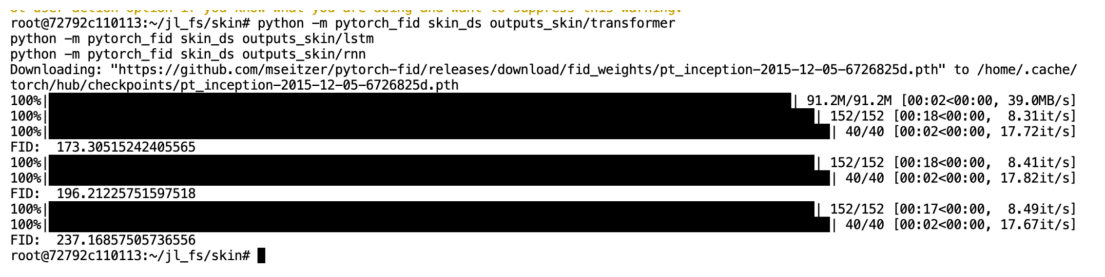

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("jl_fs/skin/fid.png")

plt.figure(figsize=(14, 14))  # 👈 increase this (try 10,10 or 12,12)
plt.imshow(img)
plt.axis("off")
plt.show()